# Practitioner Burnout Reduction Evaluation Notebook
## Stanford Professional Fulfillment Index (PFI) – Work Exhaustion / Interpersonal Disengagement Subscale

Primary metric:
Mean reduction in PFI work exhaustion / interpersonal disengagement (5-point Likert scale).
Lower scores indicate improvement.

Secondary metrics:
- Between-group difference (AI vs Control)
- Clinically meaningful improvement rate
- Number Needed to Treat (NNT)
- 24-week sustainability
- Drift detection


## 1. Setup


In [ ]:
# Standard library imports for filesystem operations and metadata export
import os
import json
from dataclasses import dataclass

# Scientific Python stack for simulation, tabular analysis, and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Central config keeps thresholds and output paths in one place
@dataclass
class Config:
    CLINICALLY_MEANINGFUL_DELTA: float = 0.44
    ARTIFACT_DIR: str = "artifacts_burnout"

cfg = Config()
# Ensure artifact folder exists before any file writes
os.makedirs(cfg.ARTIFACT_DIR, exist_ok=True)
cfg


Config(CLINICALLY_MEANINGFUL_DELTA=0.44, ARTIFACT_DIR='artifacts_burnout')

## 2. Data Structure


In [3]:
# Synthetic demo dataset (replace with real RCT data)

# Seeded RNG for reproducible demo results
rng = np.random.default_rng(2026)
n_clinicians = 120

rows = []
for cid in range(n_clinicians):
    # First half assigned to AI, second half to control
    group = "AI" if cid < n_clinicians // 2 else "CONTROL"
    baseline = rng.normal(2.8, 0.5)
    for week in [0, 4, 12, 24]:
        # Simulate stronger burnout reduction in AI arm over time
        if group == "AI":
            delta = -0.15 * (week / 4)
        else:
            delta = -0.05 * (week / 4)
        # Add measurement noise and clamp to valid 1-5 Likert bounds
        score = baseline + delta + rng.normal(0, 0.15)
        rows.append({
            "clinician_id": cid,
            "group": group,
            "week": week,
            "pfi_score": float(np.clip(score, 1, 5))
        })

df = pd.DataFrame(rows)
df.head()


,clinician_id,group,week,pfi_score
0,0,AI,0,2.439524
1,0,AI,4,1.968990
2,0,AI,12,2.162805
3,0,AI,24,1.599183
4,1,AI,0,2.607184


## 3. Primary Outcome Analysis


In [4]:
# Build baseline and week-24 snapshots for paired change analysis
baseline = df[df["week"] == 0][["clinician_id", "pfi_score"]].rename(columns={"pfi_score": "baseline"})
week24 = df[df["week"] == 24][["clinician_id", "group", "pfi_score"]].rename(columns={"pfi_score": "week24"})

# Merge per clinician and compute change (negative = improvement)
merged = week24.merge(baseline, on="clinician_id")
merged["change"] = merged["week24"] - merged["baseline"]

# Summarize mean change by treatment arm
summary = merged.groupby("group")["change"].agg(["mean", "std", "count"]).reset_index()
summary


,group,mean,std,count
0,AI,-0.848360,0.187909,60
1,CONTROL,-0.276353,0.222969,60


In [5]:
# Extract group-level means and compute between-group difference
mean_ai = summary[summary["group"] == "AI"]["mean"].values[0]
mean_ctrl = summary[summary["group"] == "CONTROL"]["mean"].values[0]
mean_diff = mean_ai - mean_ctrl

mean_ai, mean_ctrl, mean_diff


(-0.8483603017875322, -0.2763532817794055, -0.5720070200081266)

## 4. Clinically Meaningful Change & NNT


In [6]:
# Define clinically meaningful improvement threshold (negative change)
threshold = -cfg.CLINICALLY_MEANINGFUL_DELTA
merged["clinically_improved"] = merged["change"] <= threshold

# Compute improvement rate per arm
rates = merged.groupby("group")["clinically_improved"].mean().reset_index()
rates


,group,clinically_improved
0,AI,1.000000
1,CONTROL,0.233333


In [7]:
# Pull group-specific improvement rates
rate_ai = rates[rates["group"] == "AI"]["clinically_improved"].values[0]
rate_ctrl = rates[rates["group"] == "CONTROL"]["clinically_improved"].values[0]

# ARR = treatment benefit; NNT is inverse when ARR > 0
absolute_risk_reduction = rate_ai - rate_ctrl
nnt = 1 / absolute_risk_reduction if absolute_risk_reduction > 0 else float("inf")

absolute_risk_reduction, nnt


(0.7666666666666666, 1.3043478260869565)

## 5. Longitudinal Analysis (24 Weeks)


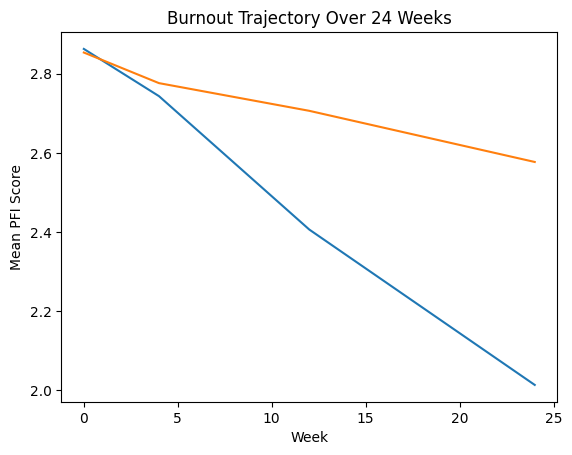

In [8]:
# Mean longitudinal trajectory per week and arm
trajectory = df.groupby(["week", "group"])["pfi_score"].mean().reset_index()

plt.figure()
for group in trajectory["group"].unique():
    sub = trajectory[trajectory["group"] == group]
    # Plot each treatment arm across follow-up timepoints
    plt.plot(sub["week"], sub["pfi_score"])
plt.xlabel("Week")
plt.ylabel("Mean PFI Score")
plt.title("Burnout Trajectory Over 24 Weeks")
plt.show()


## 6. Drift Detection


In [9]:
# Simple drift proxy: change in AI mean score from week 12 to week 24
ai_long = df[df["group"] == "AI"]
mean_12 = ai_long[ai_long["week"] == 12]["pfi_score"].mean()
mean_24 = ai_long[ai_long["week"] == 24]["pfi_score"].mean()

drift = mean_24 - mean_12
drift


-0.3923106946911248

## 7. Reporting Artifacts


In [10]:
# Build deterministic artifact filenames for this demo run
RUN_ID = "burnout_eval_demo"

summary_path = os.path.join(cfg.ARTIFACT_DIR, f"{RUN_ID}_summary.csv")
merged_path = os.path.join(cfg.ARTIFACT_DIR, f"{RUN_ID}_merged_changes.csv")
meta_path = os.path.join(cfg.ARTIFACT_DIR, f"{RUN_ID}_meta.json")

# Persist tabular outputs used for downstream QA/review
summary.to_csv(summary_path, index=False)
merged.to_csv(merged_path, index=False)

# Persist headline metrics for lightweight programmatic consumption
meta = {
    "mean_ai_change": float(mean_ai),
    "mean_control_change": float(mean_ctrl),
    "between_group_difference": float(mean_diff),
    "absolute_risk_reduction": float(absolute_risk_reduction),
    "nnt": float(nnt),
    "drift_week12_to_24": float(drift)
}

with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

summary_path, merged_path, meta_path


('artifacts_burnout\\burnout_eval_demo_summary.csv',
 'artifacts_burnout\\burnout_eval_demo_merged_changes.csv',
 'artifacts_burnout\\burnout_eval_demo_meta.json')